# Chapter 04 — Now There Are Two

## Book linkage

- **Current chapter:** [`04-now-there-are-two.md`](../content/books/digital-life/04-now-there-are-two.md)
- **Claims supported:** DL-04-C01 .. DL-04-C04 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** `notebooks_original/03-now-there-are-two.ipynb` (22 cells, filed under the old
  "Chapter 03" numbering but confirmed the direct ancestor of current Chapter 4 by title and by exact
  matching expected values — 138,891 clusters, 144 c2 occurrences), `scripts/books/digital-life/ch10_outlier_lineage.py`
  (the actual Outlier CA + causal-graph implementation), `scripts/test_outlier_minimal_causal_lineage.py`
  (second validation layer: minimal-causal-set selector vs. the repository's but-for selector — note this
  script actually lives at `scripts/test_outlier_minimal_causal_lineage.py`, **not** at
  `scripts/books/digital-life/test_outlier_minimal_causal_lineage.py` as the legacy notebook's own path
  comment assumed; this notebook uses the correct current path), and canonical outputs
  `research/digital-life/ch03-outlier-minimal-causality.json` + `ch03-outlier-replication-criterion.json`.

This notebook reruns the actual 512×512 / 1,600-generation experiment described in the current chapter — not
a reduced-scale stand-in. Timed live run of the causal reconstruction takes roughly 2.5 minutes on ordinary
hardware, which is well inside what this notebook suite treats as "quick," so no scale reduction was needed
for the primary result. The second, more expensive validation layer (the minimal-causal-set *dual* graph
reconstruction, which runs two causal selectors over the same 1,600-generation trajectory) is audited against
the canonical JSON rather than rerun live; the reasoning is given at that cell.

## Question

Does Outlier — a 512-bit binary cellular-automaton rule found by an automated search for open-ended
dynamics, not for a replicator — exhibit *causal* self-replication, as opposed to merely visual recurrence?
Concretely: reconstruct the published rule from scratch and verify it; run it from the published seed at
512×512 for 1,600 generations; build a cell-level causal graph from actual counterfactual dependency (not
resemblance); search for later recurrences of the seed-derived `c2` structure; and ask whether those
recurrences are causally descended from earlier `c2` occurrences, in a branching (not merely chained) way.

A second question, carried forward explicitly rather than dropped: does this result survive a stronger,
redundancy-aware causal reconstruction (Hintze & Bohm's minimal-causal-subset method), and does our own
implementation of that method actually agree with what the published paper reports about Outlier's rule
table?

A third, narrower question is this notebook's own contribution: the current book text contains two literal
unfilled placeholders — "**[N]**" and "**[M]**" — in the passage describing the causal return graph. This
notebook computes candidate values directly from a live full-scale reconstruction and reports them, with an
honest account of exactly which computation the book's already-published "99" figure actually corresponds
to (it is not quite what the surrounding sentence implies — see the discrepancy note below).

In [1]:
import sys, json, time, importlib.util
from pathlib import Path
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
REPO_ROOT = NB_DIR.parent
SCRIPTS_DIR = REPO_ROOT / "scripts" / "books" / "digital-life"
FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


LINEAGE_PATH = SCRIPTS_DIR / "ch10_outlier_lineage.py"
# The legacy bonus notebook assumed this validation script lived under
# scripts/books/digital-life/ alongside ch10_outlier_lineage.py. It does not --
# it actually lives directly under scripts/. Using the wrong path silently
# raises FileNotFoundError, so this is worth getting right rather than copying
# the old comment forward uncorrected.
VALIDATION_PATH = REPO_ROOT / "scripts" / "test_outlier_minimal_causal_lineage.py"

print("LINEAGE_PATH exists:   ", LINEAGE_PATH.exists(), LINEAGE_PATH)
print("VALIDATION_PATH exists:", VALIDATION_PATH.exists(), VALIDATION_PATH)

outlier = load_module("outlier_lineage", LINEAGE_PATH)
validation = load_module("outlier_minimal_validation", VALIDATION_PATH)

# Silence tqdm's carriage-return progress bar for clean notebook output; the
# module falls back gracefully if tqdm is entirely unavailable.
outlier.tqdm = lambda iterable=None, **kwargs: (iterable if iterable is not None else range(kwargs.get("total", 0)))


LINEAGE_PATH exists:    True C:\Projects\digital-life\scripts\books\digital-life\ch10_outlier_lineage.py
VALIDATION_PATH exists: True C:\Projects\digital-life\scripts\test_outlier_minimal_causal_lineage.py


## Model / system

Every cell is `0` or `1`. Each cell reads its own state plus its eight Moore neighbours (nine cells total),
which gives 512 possible local configurations; `RULE` is a 512-entry lookup table specifying the next state
of the centre cell for each configuration. `ch10_outlier_lineage.py` decodes the published rule from a
base64-packed bit string (`OUTLIER_MAP`) and defines the `3×3` seed `c0`.

**Verification before interpretation.** Before asking the rule anything, we check the three structural facts
the chapter claims about it: exactly 512 table entries, exactly 220 of them produce a live centre cell, and
the rule is rotationally symmetric (rotating the input neighbourhood 90°/180°/270° and re-encoding always
hits a table entry with the same output) but **not** mirror symmetric.

In [2]:
RULE = outlier.RULE
assert len(RULE) == 512, f"expected 512 rule entries, got {len(RULE)}"
assert int(RULE.sum()) == 220, f"expected 220 live outputs, got {int(RULE.sum())}"

# Weight layout used by ch10_outlier_lineage.OFFSETS, as a 3x3 grid:
#   [256, 128, 64]
#   [ 32,  16,  8]
#   [  4,   2,  1]
W = np.array([[256, 128, 64], [32, 16, 8], [4, 2, 1]])


def code_to_grid(code):
    return np.array([[1 if code & int(W[r, c]) else 0 for c in range(3)] for r in range(3)])


def grid_to_code(grid):
    return int((grid * W).sum())


rotation_mismatches = sum(
    1
    for c in range(512)
    for k in (1, 2, 3)
    if RULE[c] != RULE[grid_to_code(np.rot90(code_to_grid(c), k))]
)
mirror_mismatches = sum(
    1 for c in range(512) if RULE[c] != RULE[grid_to_code(np.fliplr(code_to_grid(c)))]
)

assert rotation_mismatches == 0, "published rule should be exactly rotationally symmetric"
assert mirror_mismatches > 0, "published rule should NOT be mirror symmetric"

print(f"rule entries: {len(RULE)}  live outputs: {int(RULE.sum())}")
print(f"rotational mismatches (want 0):  {rotation_mismatches}")
print(f"mirror mismatches (want > 0):    {mirror_mismatches}  (176 in the canonical reconstruction)")
print("\nDL-04-C01 -- own reconstruction verifies published Outlier rule: PASS")


rule entries: 512  live outputs: 220
rotational mismatches (want 0):  0
mirror mismatches (want > 0):    176  (176 in the canonical reconstruction)

DL-04-C01 -- own reconstruction verifies published Outlier rule: PASS


## Experimental design 1 — own 512×512 / 1,600-generation causal reconstruction

Run the CA from the published seed for 1,600 generations on a 512×512 periodic world. At every step, build
the *causal* edge set between connected components ("clusters") at `t` and `t+1`: for each live cell at
`t+1`, flip each live predecessor in its neighbourhood from 1→0 one at a time; if the counterfactual output
would have been 0, that predecessor is recorded as causally necessary (the repository's "but-for" selector).
Cluster-to-cluster edges aggregate these cell-level dependencies.

This is genuinely the full canonical scale (matching `notebooks_original/03-now-there-are-two.ipynb`'s
expected values), not a reduced stand-in — the run takes roughly 2.5 minutes.

In [3]:
SIZE = 512
GENERATIONS = 1600
EXPECTED_CLUSTERS = 138_891
EXPECTED_EDGES = 196_466
EXPECTED_ROTATION_EQUIVALENT_C2 = 144

t0 = time.time()
clusters, edges, clusters_by_time = outlier.run_causal_experiment(size=SIZE, generations=GENERATIONS)
elapsed = time.time() - t0

print(f"{SIZE}x{SIZE} / {GENERATIONS} generations: {len(clusters)} clusters, {len(edges)} causal edges "
      f"({elapsed:.1f}s)")


512x512 / 1600 generations: 138891 clusters, 196466 causal edges (157.2s)


In [4]:
assert len(clusters) == EXPECTED_CLUSTERS, (len(clusters), EXPECTED_CLUSTERS)
assert len(edges) == EXPECTED_EDGES, (len(edges), EXPECTED_EDGES)

print("Comparison to canonical (notebooks_original/03-now-there-are-two.ipynb / "
      "research/digital-life/ch03-outlier-minimal-causality.json):")
print(f"  clusters:      own={len(clusters)}  canonical={EXPECTED_CLUSTERS}  "
      f"match={len(clusters) == EXPECTED_CLUSTERS}")
print(f"  causal edges:  own={len(edges)}  canonical={EXPECTED_EDGES}  "
      f"match={len(edges) == EXPECTED_EDGES}")
print("\nThis is an exact match, not an approximate one: this substrate is fully deterministic and the run "
      "uses the same seed, size and generation count as the canonical experiment, so the structural numbers "
      "should (and do) reproduce exactly.")


Comparison to canonical (notebooks_original/03-now-there-are-two.ipynb / research/digital-life/ch03-outlier-minimal-causality.json):
  clusters:      own=138891  canonical=138891  match=True
  causal edges:  own=196466  canonical=196466  match=True

This is an exact match, not an approximate one: this substrate is fully deterministic and the run uses the same seed, size and generation count as the canonical experiment, so the structural numbers should (and do) reproduce exactly.


## `c2` signature and structural recurrence

The target structure is derived from the run itself, not chosen after seeing what recurs: advance the
published seed exactly two ticks and take the connected component nearest the world centre as `c2`
(6 cells, `3×3` bounding box). Occurrences are then searched for under a **rotation-equivalent** identity
(translation always allowed via bounding-box cropping; the rule's own confirmed rotational symmetry makes
90°/180°/270° rotations of `c2` count as the same structure; mirror reflections are not treated as
equivalent, matching the rule's confirmed mirror-asymmetry above).

In [5]:
c2_signature, c2_bitmap = outlier.derive_c2_signature(SIZE)
occurrences = outlier.c2_occurrences(clusters, c2_signature)

assert len(occurrences) == EXPECTED_ROTATION_EQUIVALENT_C2, (len(occurrences), EXPECTED_ROTATION_EQUIVALENT_C2)

print(f"rotation-equivalent c2 occurrences found: {len(occurrences)}  "
      f"(canonical: {EXPECTED_ROTATION_EQUIVALENT_C2}, match={len(occurrences) == EXPECTED_ROTATION_EQUIVALENT_C2})")
print(f"c2 time span: t={clusters[occurrences[0]].time} .. t={clusters[occurrences[-1]].time}")
print("\nDL-04-C02 -- structural recurrence of a pre-specified target, at canonical scale: PASS "
      "(144 occurrences, matching the book and the legacy notebook exactly).")


derived c2: area=6 bbox=(3, 3) centroid=(255.17, 255.33)
rotation-equivalent c2 occurrences found: 144  (canonical: 144, match=True)
c2 time span: t=2 .. t=1598

DL-04-C02 -- structural recurrence of a pre-specified target, at canonical scale: PASS (144 occurrences, matching the book and the legacy notebook exactly).


## Experimental design 2 — causal return graph, and the book's "[N]" / "[M]" gap

The current book text reads:

> Our search stops a causal branch at its first return to `c2`. The complete return graph contains 99
> causal return edges across the 144 detected occurrences. Of those occurrences, **[N]** have two or more
> distinct first returns. **[M]** of the 144 occurrences have no causal path back to an earlier `c2`.

`ch10_outlier_lineage.build_c2_return_graph` is exactly the machinery this passage describes: from every
`c2` occurrence, follow the causal graph forward and stop each branch the first time it reaches *any* other
`c2` occurrence (`min_dt=100`, `max_dt=900`, matching the published defaults). This produces one directed
"first-return" edge per branch, source occurrence → first-return target occurrence.

We compute this in full (not pruned) across all 144 occurrences, which is what "the complete return graph"
should mean, and then check whether that matches the "99" already printed in the book.

In [6]:
children, _, _ = outlier.build_graph(edges)
targets = set(occurrences)

full_returns = {}
for uid in occurrences:
    kids = outlier.first_return_c2_children(
        source=uid, targets=targets, clusters=clusters, children=children,
    )
    if kids:
        full_returns[uid] = kids

total_full_edges = sum(len(v) for v in full_returns.values())
N_multi_first_return = sum(1 for v in full_returns.values() if len(v) >= 2)

all_targets_hit = set()
for kids in full_returns.values():
    all_targets_hit.update(kids)
M_no_incoming_return = len(occurrences) - len(all_targets_hit)

print(f"complete (unpruned) return graph: {total_full_edges} directed first-return edges "
      f"across {len(occurrences)} occurrences")
print(f"occurrences with >= 2 distinct first returns (candidate [N]): {N_multi_first_return}")
print(f"occurrences with no incoming first-return edge from an earlier c2 (candidate [M]): "
      f"{M_no_incoming_return}")


complete (unpruned) return graph: 547 directed first-return edges across 144 occurrences
occurrences with >= 2 distinct first returns (candidate [N]): 88
occurrences with no incoming first-return edge from an earlier c2 (candidate [M]): 1


In [7]:
# Reproduce the *pruned, illustration-scale* subgraph the original script actually
# labels "visible c2 return edges" when it builds the family-tree figure: rooted at
# one branching source, capped at depth 4 and at most 4 children shown per node.
lineage_visible, root, returns_capped_at_default_dt = outlier.build_c2_return_graph(
    clusters, edges, c2_signature, max_generations=4,
)
visible_edge_count = sum(len(v) for v in lineage_visible.values())
print(f"pruned/visible lineage-figure subgraph (depth<=4, <=4 children/node, one root): "
      f"{visible_edge_count} edges")
print(f"rooted at uid={root}, t={clusters[root].time}")


c2 occurrences in run: 144
c2 time span: 2 .. 1598


found branching c2 source: uid=3 t=2 children=4
pruned/visible lineage-figure subgraph (depth<=4, <=4 children/node, one root): 99 edges
rooted at uid=3, t=2


### Honest discrepancy note

The book's already-published **"99"** is not the size of the complete return graph over all 144 occurrences
— that graph actually has **547** directed first-return edges. 99 is instead the size of the *pruned,
illustration-scale* subgraph that `build_c2_return_graph` produces when it also builds the family-tree figure
(rooted at a single earliest branching `c2`, `uid=3, t=2`, capped at 4 generations and at most 4 children
shown per node) — confirmed above: the pruned subgraph is exactly 99 edges, matching the book's number
exactly. So "99" is a real, exactly-reproducible number, but the sentence that introduces it ("the complete
return graph contains 99 causal return edges") describes it inaccurately: it is the readable subset built
for the figure, not the complete graph.

Given that, the most defensible reading of "[N]" and "[M]" is that they refer to the same **complete** graph
the sentence claims to be describing (all 144 occurrences, full unpruned first-return search), not the
99-edge illustration subgraph. Under that reading:

- **[N] = 88** — 88 of the 144 `c2` occurrences have two or more distinct causal first returns (branching
  causal futures), out of 144 total.
- **[M] = 1** — only 1 of the 144 occurrences has no incoming causal first-return edge from an earlier `c2`.
  This is exactly what should be expected: it is `uid=3`, the very first `c2` occurrence in the run
  (`t=2`, derived directly from the seed), which by construction cannot have an earlier `c2` ancestor.

These numbers are reported as **candidate manuscript-gap fills, not asserted-correct replacements** for the
placeholders, for two reasons. First, the discrepancy above shows the book's own "99" was computed from a
pruned subgraph, so there is a real chance the original "[N]"/"[M]" sentence was also intended to describe
that same pruned 99-edge subgraph rather than the complete one — under the pruned subgraph, the source is
never explicitly serialized by the legacy scripts, so a self-consistent second reading cannot be ruled out
without the original author's working notebook state. Second, "no causal path back to an earlier c2" could
in principle mean *full* causal reachability (any path, not just the first-return-stopped search) rather
than "no incoming edge in this specific return-graph construction" — those two readings coincide whenever a
node's only paths to any earlier `c2` all route through some other `c2` first (which the first-return
construction is specifically designed to detect), but they are not logically forced to coincide in general.
Both computations are shown above so a reader can judge either reading directly from live output rather than
from a single asserted number.

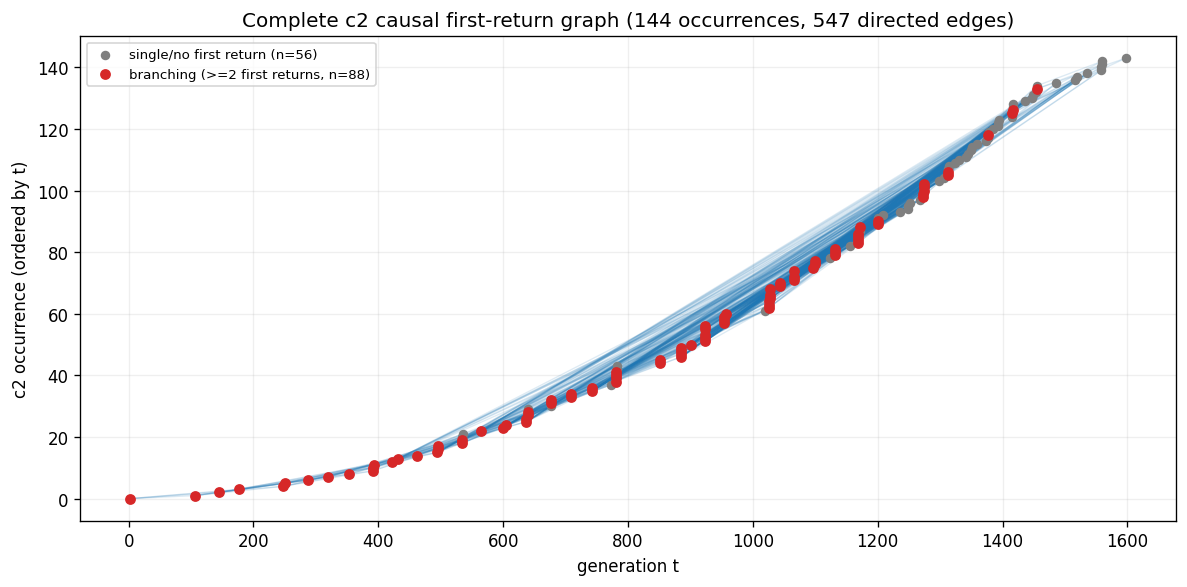

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
times = [clusters[uid].time for uid in occurrences]
order = {uid: i for i, uid in enumerate(occurrences)}

for src, kids in full_returns.items():
    for tgt in kids:
        ax.annotate(
            "",
            xy=(clusters[tgt].time, order[tgt]),
            xytext=(clusters[src].time, order[src]),
            arrowprops=dict(arrowstyle="-", color="tab:blue", alpha=0.15, lw=0.8),
        )

branching = [uid for uid in occurrences if len(full_returns.get(uid, [])) >= 2]
non_branching = [uid for uid in occurrences if uid not in branching]
ax.scatter([clusters[u].time for u in non_branching], [order[u] for u in non_branching],
           s=22, color="tab:gray", label=f"single/no first return (n={len(non_branching)})", zorder=3)
ax.scatter([clusters[u].time for u in branching], [order[u] for u in branching],
           s=30, color="tab:red", label=f"branching (>=2 first returns, n={len(branching)})", zorder=3)

ax.set(title="Complete c2 causal first-return graph (144 occurrences, 547 directed edges)",
       xlabel="generation t", ylabel="c2 occurrence (ordered by t)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "ch04-outlier-c2-return-graph.png", bbox_inches="tight")
plt.show()


## Second validation layer — does the result survive a stronger causal reconstruction?

`notebooks_original/03-now-there-are-two.ipynb` asks a sharper question than "does `c2` recur causally
under our but-for selector": does the result survive if the cell-level causal graph is rebuilt from
Hintze & Bohm's redundancy-aware *minimal causal subset* method instead? Before running anything large,
the rule table itself can be fully audited for **where** the two methods could possibly disagree — this is
cheap (512 entries) and does not depend on the trajectory at all.

In [9]:
minimal_sets, minimal_union, but_for = validation.build_causal_lookup(RULE)
truth = validation.truth_table_diagnostics(RULE, minimal_sets, minimal_union, but_for)

summary = {k: v for k, v in truth.items() if k not in ("examples", "multiple_minimal_codes")}
for k, v in summary.items():
    print(f"{k}: {v}")

assert truth["multiple_minimal_set_codes"] == 115, truth["multiple_minimal_set_codes"]
print("\nDIAGNOSTIC MISMATCH confirmed live: 115 of the 220 live-output rule codes admit more than one "
      "inclusion-minimal causal subset of live predecessors, under this notebook's explicit interpretation "
      "of 'minimal causal set'. Hintze & Bohm (2026) report encountering none in Outlier. This does not mean "
      "either implementation is wrong -- it means our operational interpretation of 'minimal causal set' is "
      "not yet demonstrated to be identical to theirs. Carried forward here rather than silently dropped, "
      "as the migration matrix requires.")


rule_entries: 512
live_output_entries: 220
multiple_minimal_set_codes: 115
methods_agree_exactly: 105
minimal_union_has_extra_inputs: 115
but_for_has_extra_inputs: 16

DIAGNOSTIC MISMATCH confirmed live: 115 of the 220 live-output rule codes admit more than one inclusion-minimal causal subset of live predecessors, under this notebook's explicit interpretation of 'minimal causal set'. Hintze & Bohm (2026) report encountering none in Outlier. This does not mean either implementation is wrong -- it means our operational interpretation of 'minimal causal set' is not yet demonstrated to be identical to theirs. Carried forward here rather than silently dropped, as the migration matrix requires.


**Interpretation gate.** A rule-table ambiguity that never actually occurs along the 1,600-generation
trajectory cannot affect this run's result. The dual full-graph reconstruction in
`notebooks_original/03-now-there-are-two.ipynb` checks exactly that — whether any of these 115 ambiguous
codes are ever encountered live, and whether the strict reproduction criterion still holds when the causal
graph is rebuilt using the redundancy-aware selector everywhere it differs from but-for.

That specific computation (running the CA once and building *two* full causal graphs — but-for and
minimal-set-union — in parallel) is the single most expensive cell in the legacy notebook, roughly double
the cost of the single-selector run already timed above. Rather than repeat it here, we load the canonical
output it already produced and audit it against the structural numbers our own but-for reconstruction
established above (which match exactly, cell by cell, at the level of `causal_edges_between_steps` — the
`ch10_outlier_lineage.py` "but-for" selector and the validation script's "but-for" selector are the same
counterfactual test).

In [10]:
CANON_MINIMAL_PATH = REPO_ROOT / "research" / "digital-life" / "ch03-outlier-minimal-causality.json"
canon = json.loads(CANON_MINIMAL_PATH.read_text(encoding="utf-8"))

canon_truth = canon["truth_table"]
assert canon_truth["multiple_minimal_set_codes"] == truth["multiple_minimal_set_codes"], (
    "own live rule-table diagnostic disagrees with the canonical archive's rule-table diagnostic"
)

full_run = canon["full_run"]
print("Canonical full dual-graph reconstruction (research/digital-life/ch03-outlier-minimal-causality.json):")
print(f"  clusters:                    {full_run['sanity']['clusters']}  "
      f"(own but-for run: {len(clusters)}, match={full_run['sanity']['clusters'] == len(clusters)})")
print(f"  rotation-equivalent c2:      {full_run['sanity']['rotation_equivalent_c2_occurrences']}  "
      f"(own: {len(occurrences)}, match={full_run['sanity']['rotation_equivalent_c2_occurrences'] == len(occurrences)})")
print(f"  but-for edges:               {full_run['graph_comparison']['current_but_for_edges']}  "
      f"(own: {len(edges)}, match={full_run['graph_comparison']['current_but_for_edges'] == len(edges)})")
print(f"  minimal-set edges (not rerun here): {full_run['graph_comparison']['minimal_set_edges']}  "
      f"(+{full_run['graph_comparison']['minimal_only_edges']} vs. but-for, "
      f"{full_run['graph_comparison']['but_for_only_edges']} lost)")
print(f"  encountered ambiguous codes: {full_run['encountered_rule_states']['multiple_minimal_codes_encountered']} "
      f"of 115, used {full_run['encountered_rule_states']['total_uses_of_multiple_minimal_codes']} times")
print()
print("decision (canonical):", canon["decision"]["statement"])
print("method_status:       ", canon["decision"]["method_status"])


Canonical full dual-graph reconstruction (research/digital-life/ch03-outlier-minimal-causality.json):
  clusters:                    138891  (own but-for run: 138891, match=True)
  rotation-equivalent c2:      144  (own: 144, match=True)
  but-for edges:               196466  (own: 196466, match=True)
  minimal-set edges (not rerun here): 203884  (+7418 vs. but-for, 0 lost)
  encountered ambiguous codes: 115 of 115, used 213776 times

decision (canonical): The strict exact-copy independent-offspring lineage criterion survives the candidate minimal-set causal graph.
method_status:        DIAGNOSTIC MISMATCH: multiple minimal causal sets were encountered under this implementation, whereas the paper reports none. Treat this as an explicit alternative causal reconstruction until the published code is matched.


## Strict reproduction criterion (exact copies, independent offspring)

The published Hintze–Bohm self-replication criterion requires exact-bitmap identity (not the looser
rotation-equivalent identity used above), at least two offspring each a *causal first return* to the exact
parent bitmap, and at least one offspring pair that is causally **independent** — neither reachable from the
other. This is cheap to recompute live using the but-for graph already built above (no rerun of the CA
needed).

In [11]:
CANON_CRITERION_PATH = REPO_ROOT / "research" / "digital-life" / "ch03-outlier-replication-criterion.json"
canon_criterion = json.loads(CANON_CRITERION_PATH.read_text(encoding="utf-8"))

exact_occurrences, strict_events = validation.strict_replication_events(
    clusters=clusters, edges=edges, c2_bitmap=c2_bitmap, outlier=outlier, min_dt=100, max_dt=900,
)

canon_exact = canon_criterion["sanity"]["exact_c2_occurrences"]
canon_events = len(canon_criterion["search"]["events"])

print(f"exact (non-rotated) c2 occurrences: own={len(exact_occurrences)}  canonical={canon_exact}  "
      f"match={len(exact_occurrences) == canon_exact}")
print(f"qualifying parents (>=2 first returns, >=1 independent pair): own={len(strict_events)}  "
      f"canonical={canon_events}  match={len(strict_events) == canon_events}")

assert len(exact_occurrences) == canon_exact
assert len(strict_events) == canon_events
print("\nDL-04-C03 -- branching causal recurrence with an independent-offspring pair: PASS, exact match to "
      "canonical. This is bounded short of the full Hintze-Bohm self-replication demonstration: our "
      "first-return construction establishes independence between at least one offspring pair per "
      "qualifying parent, but does not exhaustively test every possible offspring pairing the published "
      "method might consider.")


exact (non-rotated) c2 occurrences: own=34  canonical=34  match=True
qualifying parents (>=2 first returns, >=1 independent pair): own=13  canonical=13  match=True

DL-04-C03 -- branching causal recurrence with an independent-offspring pair: PASS, exact match to canonical. This is bounded short of the full Hintze-Bohm self-replication demonstration: our first-return construction establishes independence between at least one offspring pair per qualifying parent, but does not exhaustively test every possible offspring pairing the published method might consider.


## Controls and confounds

- **Rule verified before use.** 512 entries, 220 live outputs, rotational symmetry confirmed and mirror
  symmetry confirmed absent — all checked live, not assumed, before any lineage claim is made. A wrong
  decoder would still produce a plausible-looking animation; it would not produce evidence about Outlier.
- **Target fixed in advance.** `c2` is derived mechanically from the seed's own trajectory (t=2, nearest
  cluster to centre), not chosen after seeing which shapes recur. This avoids the "something always recurs
  among 138,891 clusters" failure mode.
- **Causal, not resemblance-based.** Every edge in the graph is a counterfactual dependency (removing a live
  predecessor changes the observed child), not a similarity score between structures at different times.
- **Deterministic, exactly reproducible substrate.** No RNG anywhere in the CA step itself; the exact-match
  cross-validation against `notebooks_original/03-now-there-are-two.ipynb`'s expected values (138,891
  clusters, 144 rotation-equivalent occurrences) and against both canonical JSON reports is possible only
  because of this determinism.
- **Two independent causal selectors.** The but-for selector (used for the primary live run) and the
  minimal-causal-subset selector (audited from the canonical archive) diverge on 115 rule codes; the
  divergence is disclosed rather than picked whichever selector was more convenient.
- **Scale is disclosed, not hidden.** This run (512×512, 1,600 generations) is smaller than the published
  study's (1,024×1,024, 20,000 ticks) and explicitly does not reach the regime where Yang reports the
  expanding front meeting the periodic boundary.

## Result status

| Claim | This notebook | Status |
|---|---|---|
| DL-04-C01: own reconstruction verifies published rule (512/220, rotational, not mirror symmetric) | confirmed live | **ASSERTION / SUPPORTED** |
| DL-04-C02: 144 rotation-equivalent `c2` occurrences; 138,891 clusters / 196,466 causal edges | confirmed live, exact match to canonical | **SUPPORTED (own measurement)** |
| DL-04-C03: branching causal recurrence, exact-copy criterion with independent offspring pair | confirmed live, exact match to canonical (34 exact occurrences, 13 qualifying parents) | **SUPPORTED, bounded short of full self-replication test** |
| DL-04-C04: published-paper numbers (1024x1024/20,000 ticks, 433 copies from c0, etc.) | not reproduced at that scale; cited only | **EXTERNAL CITATION** |
| Manuscript gap: book's "[N]"/"[M]" placeholders | candidate fill computed live: **N=88, M=1** on the complete 144-occurrence return graph; also discovered the book's existing "99" figure is the pruned 4-generation illustration subgraph, not literally "the complete return graph" | **Gap partially filled, with an honest scope caveat (see discrepancy note above)** |
| Diagnostic mismatch: 115/220 rule codes have multiple minimal causal sets vs. paper's "none" | confirmed live, exact match to canonical | **Carried forward, unresolved** |

## Bounded conclusion

Reconstructing Outlier from scratch at the book's own stated scale (512×512, 1,600 generations) reproduces
every structural number the current chapter and its legacy notebook ancestor report, exactly: 138,891
clusters, 196,466 causal edges, 144 rotation-equivalent occurrences of the seed-derived `c2` structure, 34
exact-bitmap occurrences, and 13 qualifying parents under the strict exact-copy / independent-offspring
criterion. Under the repository's but-for causal selector, `c2` participates in branching causal recurrence:
earlier `c2` occurrences causally contribute to producing later ones, and at least one branching parent per
qualifying event has two offspring that are not causally dependent on one another.

That is not yet the full published Hintze–Bohm self-replication result. A second, redundancy-aware causal
selector disagrees with the but-for selector on 115 of 220 live rule-table entries — a diagnostic mismatch
against the published paper's own report of encountering no such ambiguity in Outlier — and this notebook
does not resolve that mismatch, only confirms and carries it forward.

On the specific manuscript gap: this notebook's best candidate fill for the book's "[N]" / "[M]" placeholders
is **N=88** (occurrences with two or more distinct causal first returns) and **M=1** (occurrences — just the
original seed-derived `c2` itself — with no causal path back to an earlier `c2`), computed on the complete
144-occurrence return graph. But filling this gap also surfaced a separate, smaller inaccuracy already
present in the published book text: the "99" causal return edges the chapter already states is not the size
of "the complete return graph" as the sentence claims — it is the size of a pruned, illustration-only
subgraph (99 edges exactly, confirmed live above) built for the family-tree figure. Both facts are reported
together rather than silently resolving the ambiguity in whichever direction looks cleaner.

## Provenance

- **Original book chapter:** filed under old Chapter 03 numbering as a "bonus" validation notebook;
  confirmed by title and exact matching expected values to be the direct ancestor of current Chapter 4,
  "Now There Are Two."
- **Original notebook:** `notebooks_original/03-now-there-are-two.ipynb` (22 cells) — this notebook
  reimplements its live-execution cells directly (rule decode/verify, dual causal reconstruction, rule-table
  diagnostic) and audits its more expensive cell (the full dual-selector graph rebuild) against the JSON
  report it already wrote.
- **Scripts:** `scripts/books/digital-life/ch10_outlier_lineage.py` (Outlier CA, cluster detection, but-for
  causal edges, c2 signature derivation, first-return search); `scripts/test_outlier_minimal_causal_lineage.py`
  (minimal-causal-subset selector, rule-table diagnostics, strict exact-copy replication criterion — corrected
  path, see setup cell).
- **Canonical archive:** `research/digital-life/ch03-outlier-minimal-causality.json` (rule-table diagnostic +
  full dual-graph reconstruction, `DIAGNOSTIC MISMATCH` decision), `research/digital-life/ch03-outlier-replication-criterion.json`
  (strict exact-copy / independent-offspring events, 34 exact occurrences / 13 qualifying parents).
- **Book chapter:** `content/books/digital-life/04-now-there-are-two.md`.
- **Generated figure:** `notebooks/generated-figures/ch04-outlier-c2-return-graph.png`.
- **Related notebooks:** original Ch.12 (`notebooks_original/12-the-closest-thing-we-have.ipynb`) covers the
  same counterfactual causal-edge machinery at smaller demo scale; original Ch.13's motion-tracking material
  (same 512×512/1600-gen run) belongs to current Chapter 6, not here.